# Benchmarking ML Algorithms to Predict Mortality due to Sepsis

In [11]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score, make_scorer

In [12]:
# Load the data file and rearrange the dataset such that predictors and response are column values
data = pd.read_csv('../data/Netea_balanced_combat_corrected_data_with_meta.csv', header = None, low_memory = False)
data_T = data
#data_T = data.transpose()
data_T.columns = data_T.iloc[0]

# Set the first row as column headers
data_T.columns = data_T.iloc[0]
data_T = data_T.drop(data_T.index[0]).reset_index(drop=True)

# Convert all columns to their appropriate data types
data_T = data_T.apply(pd.to_numeric, errors='ignore')
data_T

,ABCE1,AEBP2,ALG8,ATR,BCAS2,BTBD1,BTF3L4,BUB3,BZW2,C1QBP,...,ZNF14,ZNF227,ZNF432,ZNF559,ZNF567,ZNF75A,ZZZ3,Age,Gender,Mortality
0,5.770311,4.589610,5.652066,3.353692,4.284542,5.775141,6.736516,5.665864,6.787793,7.921607,...,6.492971,5.059673,4.155566,5.319324,3.188752,5.539237,5.376234,70.0,0.0,1.0
1,5.533009,4.287022,5.273277,3.790109,4.702455,5.760993,5.186812,5.436241,6.230216,7.538863,...,7.843215,4.518375,3.471271,4.040525,2.591724,5.180422,4.868028,64.0,0.0,0.0
2,5.695098,5.181174,5.882368,3.616235,4.164561,5.592875,5.937123,5.918471,6.309521,7.661305,...,6.850420,4.895723,4.685410,5.318127,4.562189,5.528094,5.217875,47.0,0.0,0.0
3,6.198338,5.296979,6.007996,3.847902,5.057245,5.960527,6.407928,6.374387,6.777255,7.987149,...,7.185452,5.226771,3.840383,5.871458,4.114712,4.457478,5.559887,71.0,1.0,0.0
4,4.393348,5.133299,5.112961,2.570163,5.432136,5.673157,6.683321,4.896105,6.054430,7.064439,...,6.948592,4.233512,4.323946,5.239863,3.363389,5.019400,4.329254,45.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1269,3.903820,5.230591,5.223104,2.599398,5.093161,5.204884,5.394027,6.203443,4.891176,6.771998,...,5.760337,4.492570,4.341182,4.315319,3.287326,3.625147,4.160304,NaN,NaN,NaN
1270,5.228622,4.706379,5.137463,3.761183,3.612331,6.231513,3.713300,6.263361,6.068721,7.110198,...,6.271777,4.484931,4.181697,5.672060,3.896525,4.857208,3.334883,46.0,0.0,1.0
1271,4.198483,4.665506,4.601973,4.322768,5.129983,6.858358,5.397138,5.680721,4.784136,6.608868,...,7.495406,5.694720,4.352732,5.369161,3.241148,5.296148,4.676963,78.0,1.0,1.0
1272,5.245201,4.513889,5.417744,4.221374,5.354042,5.358715,6.207254,6.059384,6.334499,7.862770,...,6.796388,4.897231,3.721894,3.450040,3.927769,4.431092,5.412169,53.0,1.0,1.0


In [13]:
data_T.shape

(1274, 197)

In [14]:
data_T.describe()

,ABCE1,AEBP2,ALG8,ATR,BCAS2,BTBD1,BTF3L4,BUB3,BZW2,C1QBP,...,ZNF14,ZNF227,ZNF432,ZNF559,ZNF567,ZNF75A,ZZZ3,Age,Gender,Mortality
count,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000,...,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000,1274.000000,1272.000000,1272.000000,1272.000000
mean,5.148147,4.821430,4.985997,3.887474,4.642206,5.906117,5.872410,5.896401,5.841609,7.294926,...,7.469755,4.922044,4.273578,5.030202,3.663301,4.775548,5.055488,62.162736,0.425314,0.227201
std,0.992409,0.584096,0.658786,0.652792,0.630633,0.754783,0.688972,0.598081,0.783892,0.722625,...,0.612042,0.564537,0.539872,0.721869,0.499555,0.562662,0.625216,17.070025,0.494585,0.419188
min,1.712755,2.872101,2.948606,1.993551,2.717616,3.018341,2.362512,4.012647,2.207984,4.774809,...,5.021183,2.683450,2.370151,2.567001,1.953264,2.580332,3.144032,18.000000,0.000000,0.000000
25%,4.465293,4.400692,4.524716,3.426128,4.225968,5.410372,5.455401,5.478473,5.345098,6.812178,...,7.035573,4.526432,3.903347,4.523563,3.301924,4.383934,4.602351,52.000000,0.000000,0.000000
50%,5.170144,4.832523,5.002200,3.887171,4.658996,5.982795,5.952504,5.886531,5.882212,7.310231,...,7.442540,4.927696,4.247869,5.065907,3.621664,4.780716,5.027516,65.000000,0.000000,0.000000
75%,5.846242,5.219040,5.448765,4.345480,5.097760,6.467903,6.361570,6.308767,6.376687,7.787610,...,7.899872,5.306975,4.637135,5.523649,3.981812,5.180066,5.481178,76.000000,1.000000,0.000000
max,7.933583,6.703800,6.992527,6.079293,6.424042,7.620680,7.640427,7.657974,8.036883,9.689869,...,9.466150,6.511690,6.715995,6.996296,5.868019,6.722758,6.924423,96.000000,1.000000,1.000000


In [15]:
# Check for null values in the dataset
data_T.isnull().sum()

0
ABCE1        0
AEBP2        0
ALG8         0
ATR          0
BCAS2        0
            ..
ZNF75A       0
ZZZ3         0
Age          2
Gender       2
Mortality    2
Length: 197, dtype: int64

In [16]:
# Display the rows which have null value in any column
null_rows = data_T[data_T.isnull().any(axis = 1)]
null_rows

,ABCE1,AEBP2,ALG8,ATR,BCAS2,BTBD1,BTF3L4,BUB3,BZW2,C1QBP,...,ZNF14,ZNF227,ZNF432,ZNF559,ZNF567,ZNF75A,ZZZ3,Age,Gender,Mortality
1261,4.670542,4.509714,4.708505,3.279055,4.632068,4.916904,6.720835,5.141182,5.464221,6.962750,...,6.388534,4.425334,4.210484,5.222485,3.209859,4.445630,4.224552,NaN,NaN,NaN
1269,3.903820,5.230591,5.223104,2.599398,5.093161,5.204884,5.394027,6.203443,4.891176,6.771998,...,5.760337,4.492570,4.341182,4.315319,3.287326,3.625147,4.160304,NaN,NaN,NaN


In [17]:
null_rows = data_T[data_T.isnull().any(axis = 1)]
null_rows

,ABCE1,AEBP2,ALG8,ATR,BCAS2,BTBD1,BTF3L4,BUB3,BZW2,C1QBP,...,ZNF14,ZNF227,ZNF432,ZNF559,ZNF567,ZNF75A,ZZZ3,Age,Gender,Mortality
1261,4.670542,4.509714,4.708505,3.279055,4.632068,4.916904,6.720835,5.141182,5.464221,6.962750,...,6.388534,4.425334,4.210484,5.222485,3.209859,4.445630,4.224552,NaN,NaN,NaN
1269,3.903820,5.230591,5.223104,2.599398,5.093161,5.204884,5.394027,6.203443,4.891176,6.771998,...,5.760337,4.492570,4.341182,4.315319,3.287326,3.625147,4.160304,NaN,NaN,NaN


In [19]:
# Check for class imbalance
survived_cases = (data_T['Mortality'] == 0).sum()
survived_cases

983

In [20]:
death_cases = (data_T['Mortality'] == 1).sum()
death_cases

289

In [25]:
data_T

,ABCE1,AEBP2,ALG8,ATR,BCAS2,BTBD1,BTF3L4,BUB3,BZW2,C1QBP,...,ZNF14,ZNF227,ZNF432,ZNF559,ZNF567,ZNF75A,ZZZ3,Age,Gender,Mortality
0,5.770311,4.589610,5.652066,3.353692,4.284542,5.775141,6.736516,5.665864,6.787793,7.921607,...,6.492971,5.059673,4.155566,5.319324,3.188752,5.539237,5.376234,70.0,0.0,1.0
1,5.533009,4.287022,5.273277,3.790109,4.702455,5.760993,5.186812,5.436241,6.230216,7.538863,...,7.843215,4.518375,3.471271,4.040525,2.591724,5.180422,4.868028,64.0,0.0,0.0
2,5.695098,5.181174,5.882368,3.616235,4.164561,5.592875,5.937123,5.918471,6.309521,7.661305,...,6.850420,4.895723,4.685410,5.318127,4.562189,5.528094,5.217875,47.0,0.0,0.0
3,6.198338,5.296979,6.007996,3.847902,5.057245,5.960527,6.407928,6.374387,6.777255,7.987149,...,7.185452,5.226771,3.840383,5.871458,4.114712,4.457478,5.559887,71.0,1.0,0.0
4,4.393348,5.133299,5.112961,2.570163,5.432136,5.673157,6.683321,4.896105,6.054430,7.064439,...,6.948592,4.233512,4.323946,5.239863,3.363389,5.019400,4.329254,45.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1269,3.903820,5.230591,5.223104,2.599398,5.093161,5.204884,5.394027,6.203443,4.891176,6.771998,...,5.760337,4.492570,4.341182,4.315319,3.287326,3.625147,4.160304,65.0,0.0,0.0
1270,5.228622,4.706379,5.137463,3.761183,3.612331,6.231513,3.713300,6.263361,6.068721,7.110198,...,6.271777,4.484931,4.181697,5.672060,3.896525,4.857208,3.334883,46.0,0.0,1.0
1271,4.198483,4.665506,4.601973,4.322768,5.129983,6.858358,5.397138,5.680721,4.784136,6.608868,...,7.495406,5.694720,4.352732,5.369161,3.241148,5.296148,4.676963,78.0,1.0,1.0
1272,5.245201,4.513889,5.417744,4.221374,5.354042,5.358715,6.207254,6.059384,6.334499,7.862770,...,6.796388,4.897231,3.721894,3.450040,3.927769,4.431092,5.412169,53.0,1.0,1.0


In [22]:
# Impute NaN values
age_med = data_T['Age'].median()
data_T['Age'] = data_T['Age'].fillna(age_med)

gender_mode = data_T['Gender'].mode()[0]
data_T['Gender'] = data_T['Gender'].fillna(gender_mode)

mortality_mode = data_T['Mortality'].mode()[0]
data_T['Mortality'] = data_T['Mortality'].fillna(mortality_mode)

In [23]:
null_rows = data_T[data_T.isnull().any(axis = 1)]
null_rows

,ABCE1,AEBP2,ALG8,ATR,BCAS2,BTBD1,BTF3L4,BUB3,BZW2,C1QBP,...,ZNF14,ZNF227,ZNF432,ZNF559,ZNF567,ZNF75A,ZZZ3,Age,Gender,Mortality


In [26]:
# Encode the 'Sex' and Mortality' columns
#label_encoder = LabelEncoder()
#data_T['Mortality '] = label_encoder.fit_transform(data_T['Mortality '].astype(str))

#data_T['Gender'] = label_encoder.fit_transform(data_T['Gender'].astype(str))

# Define predictor and response variables
X = data_T.iloc[:,:-1]
y = data_T['Mortality']

In [27]:
X

,ABCE1,AEBP2,ALG8,ATR,BCAS2,BTBD1,BTF3L4,BUB3,BZW2,C1QBP,...,ZMYM4,ZNF14,ZNF227,ZNF432,ZNF559,ZNF567,ZNF75A,ZZZ3,Age,Gender
0,5.770311,4.589610,5.652066,3.353692,4.284542,5.775141,6.736516,5.665864,6.787793,7.921607,...,5.688253,6.492971,5.059673,4.155566,5.319324,3.188752,5.539237,5.376234,70.0,0.0
1,5.533009,4.287022,5.273277,3.790109,4.702455,5.760993,5.186812,5.436241,6.230216,7.538863,...,4.381350,7.843215,4.518375,3.471271,4.040525,2.591724,5.180422,4.868028,64.0,0.0
2,5.695098,5.181174,5.882368,3.616235,4.164561,5.592875,5.937123,5.918471,6.309521,7.661305,...,5.544296,6.850420,4.895723,4.685410,5.318127,4.562189,5.528094,5.217875,47.0,0.0
3,6.198338,5.296979,6.007996,3.847902,5.057245,5.960527,6.407928,6.374387,6.777255,7.987149,...,5.948193,7.185452,5.226771,3.840383,5.871458,4.114712,4.457478,5.559887,71.0,1.0
4,4.393348,5.133299,5.112961,2.570163,5.432136,5.673157,6.683321,4.896105,6.054430,7.064439,...,4.909883,6.948592,4.233512,4.323946,5.239863,3.363389,5.019400,4.329254,45.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1269,3.903820,5.230591,5.223104,2.599398,5.093161,5.204884,5.394027,6.203443,4.891176,6.771998,...,4.847248,5.760337,4.492570,4.341182,4.315319,3.287326,3.625147,4.160304,65.0,0.0
1270,5.228622,4.706379,5.137463,3.761183,3.612331,6.231513,3.713300,6.263361,6.068721,7.110198,...,4.866927,6.271777,4.484931,4.181697,5.672060,3.896525,4.857208,3.334883,46.0,0.0
1271,4.198483,4.665506,4.601973,4.322768,5.129983,6.858358,5.397138,5.680721,4.784136,6.608868,...,5.657799,7.495406,5.694720,4.352732,5.369161,3.241148,5.296148,4.676963,78.0,1.0
1272,5.245201,4.513889,5.417744,4.221374,5.354042,5.358715,6.207254,6.059384,6.334499,7.862770,...,5.269470,6.796388,4.897231,3.721894,3.450040,3.927769,4.431092,5.412169,53.0,1.0


In [28]:
y

0       1.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
1269    0.0
1270    1.0
1271    1.0
1272    1.0
1273    1.0
Name: Mortality, Length: 1274, dtype: float64

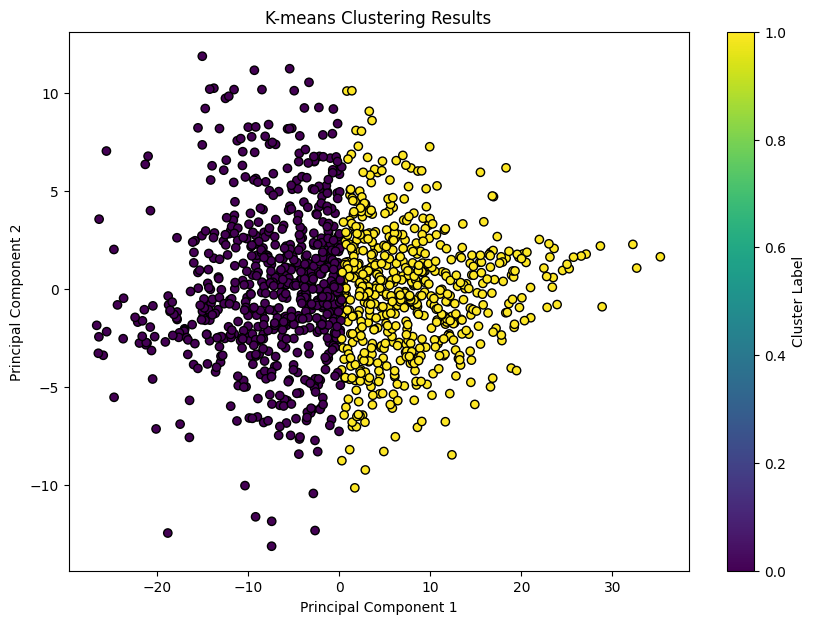

In [29]:
# Standardize the data and visualize to see data complexity
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Apply K-means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_pca)
labels = kmeans.labels_

# Plot the results
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k')
plt.title('K-means Clustering Results')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

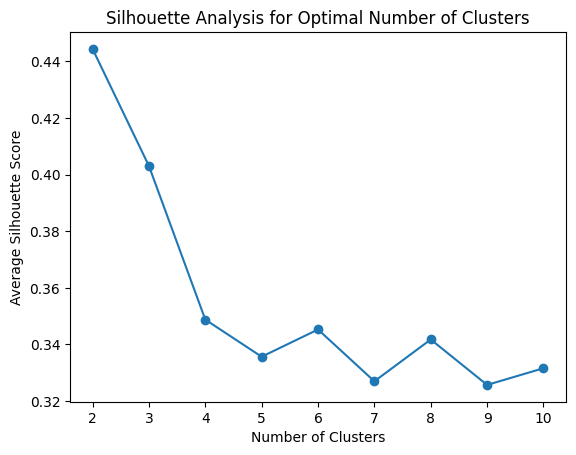

In [30]:
# Silhouette analysis for different number of clusters
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot silhouette scores
plt.figure()
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Analysis for Optimal Number of Clusters')
plt.show()

In [31]:
# Function to split the data into training and testing sets using only significant features
def split_data(features, response, testsize):
    X_train, X_test, y_train, y_test = train_test_split(features, response, test_size = testsize, random_state = 42)
    return X_train, X_test, y_train, y_test

In [32]:
# Get train and test data
X_train, X_test, y_train, y_test = split_data(X, y, 0.2)

### Train classifiers

In [33]:
# Function for AdaBoost classifier
def ada_boost(train_features, response, test_features):
    ada_params = {
        'classifier__n_estimators': [50, 100, 200, 300, 500],
        'classifier__learning_rate': [0.001, 0.01, 0.1, 1, 10]
    }
    
    ada_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', AdaBoostClassifier(random_state=42))
    ])
    
    grid_search_ada = GridSearchCV(
        ada_pipeline,
        param_grid=ada_params,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    grid_search_ada.fit(train_features, response)
    
    best_ada = grid_search_ada.best_estimator_
    y_pred_ada = best_ada.predict(test_features)
    best_params_ada = pd.DataFrame([grid_search_ada.best_params_], columns=grid_search_ada.best_params_.keys())
    
    return y_pred_ada, best_ada, best_params_ada

In [34]:
model_ada, best_ada, best_params_ada = ada_boost(X_train, y_train, X_test) 

In [35]:
conf_matrix_ada = confusion_matrix(y_test, model_ada)

In [38]:
# Function for SVM classifier
def svm_model(train_features, response, test_features):
    svm_params = {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
        'classifier__gamma': ['scale', 'auto']
    }
    
    svm_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', SVC(probability=True, random_state=42))
    ])

    grid_search_svm = GridSearchCV(
        svm_pipeline,
        param_grid=svm_params,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid_search_svm.fit(train_features, response)

    best_svm = grid_search_svm.best_estimator_
    y_pred_svm = best_svm.predict(test_features)
    best_params_svm = pd.DataFrame([grid_search_svm.best_params_], columns=grid_search_svm.best_params_.keys())
    
    return y_pred_svm, best_svm, best_params_svm

In [39]:
model_svm, best_svm, best_params_svm = svm_model(X_train, y_train, X_test)

In [40]:
conf_matrix_svm = confusion_matrix(y_test, model_svm)

In [41]:
# Function for LDA classifier
def lda_model(train_features, response, test_features):
    lda_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', LinearDiscriminantAnalysis())
    ])

    grid_search_lda = GridSearchCV(
        lda_pipeline,
        param_grid={},
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid_search_lda.fit(train_features, response)

    best_lda = grid_search_lda.best_estimator_
    y_pred_lda = best_lda.predict(test_features)

    return y_pred_lda, best_lda, {}

In [42]:
model_lda, best_lda, best_params_lda = lda_model(X_train, y_train, X_test)

In [43]:
conf_matrix_lda = confusion_matrix(y_test, model_lda)

In [44]:
# Function for Random Forest classifier
def random_forest(train_features, response, test_features):
    rf_params = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
    }
    rf_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    grid_search_rf = GridSearchCV(
        rf_pipeline,
        param_grid=rf_params,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid_search_rf.fit(train_features, response)

    best_rf = grid_search_rf.best_estimator_
    y_pred_rf = best_rf.predict(test_features)
    best_params_rf = pd.DataFrame([grid_search_rf.best_params_], columns=grid_search_rf.best_params_.keys())
    
    return y_pred_rf, best_rf, best_params_rf

In [45]:
model_rf, best_rf, best_params_rf = random_forest(X_train, y_train, X_test)

In [46]:
conf_matrix_rf = confusion_matrix(y_test, model_rf)

In [47]:
# Apply Voting Classifier
def voting_classifier(X_train, y_train, X_test):
    ada = AdaBoostClassifier(
        random_state=42, 
        n_estimators=best_params_ada['classifier__n_estimators'][0],
        learning_rate=best_params_ada['classifier__learning_rate'][0]
    )
    
    svm = SVC(
        C=best_params_svm['classifier__C'][0], 
        kernel=best_params_svm['classifier__kernel'][0], 
        gamma=best_params_svm['classifier__gamma'][0], 
        probability=True, 
        random_state=42
    )
    
    lda = LinearDiscriminantAnalysis()
    
    rf = RandomForestClassifier(
        random_state=42, 
        n_estimators=best_params_rf['classifier__n_estimators'][0],
        max_depth=best_params_rf['classifier__max_depth'][0], 
        min_samples_split=best_params_rf['classifier__min_samples_split'][0], 
        min_samples_leaf=best_params_rf['classifier__min_samples_leaf'][0]
    )

    # Define Voting Classifier with component models
    voting_clf = VotingClassifier(estimators=[
        ('ada', ada),
        ('svm', svm),
        ('lda', lda),
        ('rf', rf)
    ])

    voting_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('voting', voting_clf)
    ])

    voting_params = {
        'voting__voting': ['soft', 'hard']
    }

    grid_search_voting = GridSearchCV(
        voting_pipeline, 
        voting_params, 
        cv=5, 
        scoring='roc_auc',
        n_jobs=-1
    )

    grid_search_voting.fit(X_train, y_train)

    best_voting = grid_search_voting.best_estimator_
    y_pred_voting = best_voting.predict(X_test)
    best_params_voting = pd.DataFrame([grid_search_voting.best_params_], columns=grid_search_voting.best_params_.keys())
    
    return y_pred_voting, best_voting, best_params_voting

In [48]:
# Train and evaluate Voting Classifier with original data
model_voting, best_voting, best_params_voting = voting_classifier(X_train, y_train, X_test)

/Users/shreyalakshman/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/shreyalakshman/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/shreyalakshman/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/shreyalakshman/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method

In [49]:
conf_matrix_voting = confusion_matrix(y_test, model_voting)

In [51]:
# Display confusion matrices
print("\nAdaboost confusion matrix:")
print(conf_matrix_ada)
print("\nSVM confusion matrix:")
print(conf_matrix_svm)
print("\nLDA confusion matrix:")
print(conf_matrix_lda)
print("\nRandom Forest confusion matrix:")
print(conf_matrix_rf)
print("\nVoting Classifier confusion matrix:")
print(conf_matrix_voting)


Adaboost confusion matrix:
[[152  45]
 [ 37  21]]

SVM confusion matrix:
[[177  20]
 [ 40  18]]

LDA confusion matrix:
[[129  68]
 [ 25  33]]

Random Forest confusion matrix:
[[183  14]
 [ 52   6]]

Voting Classifier confusion matrix:
[[181  16]
 [ 42  16]]


In [53]:
# Evaluation
acc_ada = accuracy_score(y_test, model_ada)
print("\nBest parameters for AdaBoost:")
print(best_params_ada)
print("\nAdaBoost Classifier Report")
print(classification_report(y_test, model_ada))
print("Accuracy:", acc_ada)

acc_svm = accuracy_score(y_test, model_svm)
print("\nBest parameters for SVM:")
print(best_params_svm)
print("\nSVM Report")
print(classification_report(y_test, model_svm))
print("Accuracy:", acc_svm)

acc_lda = accuracy_score(y_test, model_lda)
print("\nLDA Report")
print(classification_report(y_test, model_lda))
print("Accuracy:", acc_lda)

acc_rf = accuracy_score(y_test, model_rf)
print("\nBest parameters for Random Forest:")
print(best_params_rf)
print("\nRandom Forest Classifier Report")
print(classification_report(y_test, model_rf))
print("Accuracy:", acc_rf)

acc_voting = accuracy_score(y_test, model_voting)
print("\nBest parameters for Voting Classifier:")
print(best_params_voting)
print("\nVoting Classifier Report")
print(classification_report(y_test, model_voting))
print("Accuracy:", acc_voting)


Best parameters for AdaBoost:
   classifier__learning_rate  classifier__n_estimators
0                          1                       300

AdaBoost Classifier Report
              precision    recall  f1-score   support

         0.0       0.80      0.77      0.79       197
         1.0       0.32      0.36      0.34        58

    accuracy                           0.68       255
   macro avg       0.56      0.57      0.56       255
weighted avg       0.69      0.68      0.69       255

Accuracy: 0.6784313725490196

Best parameters for SVM:
   classifier__C classifier__gamma classifier__kernel
0            100              auto                rbf

SVM Report
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86       197
         1.0       0.47      0.31      0.38        58

    accuracy                           0.76       255
   macro avg       0.64      0.60      0.62       255
weighted avg       0.74      0.76      0.75       255

Ac

### Apply PCA to perform dimensionality reduction and then use classifiers

In [54]:
# PCA Feature Selector Class
class PCASignificantFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, significance_level=0.05):
        n_components = min(X_train.shape[0], X_train.shape[1], 600)
        self.significance_level = significance_level

    def fit(self, X, y=None):
        self.n_components = min(X.shape[0], X.shape[1], 600)
        self.pca = PCA(n_components=self.n_components, random_state=42)
        X_pca = self.pca.fit_transform(X)
        f_values, p_values = f_classif(X_pca, y)
        self.significant_mask = p_values < self.significance_level
        return self

    def transform(self, X):
        X_pca = self.pca.transform(X)
        return X_pca[:, self.significant_mask]

def build_pipeline_with_pca(model, param_grid):
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('pca_selector', PCASignificantFeatureSelector()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    return grid_search

def ada_boost_pca(train_features, response, test_features):
    ada_params = {
        'classifier__n_estimators': [50, 100, 200, 300, 500],
        'classifier__learning_rate': [0.001, 0.01, 0.1, 1, 10]
    }
    grid_search_ada = build_pipeline_with_pca(AdaBoostClassifier(random_state=42), ada_params)
    grid_search_ada.fit(train_features, response)
    
    best_ada = grid_search_ada.best_estimator_
    y_pred_ada = best_ada.predict(test_features)
    best_params_ada = pd.DataFrame([grid_search_ada.best_params_], columns=grid_search_ada.best_params_.keys())
    
    return y_pred_ada, best_ada, best_params_ada

def svm_model_pca(train_features, response, test_features):
    svm_params = {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
        'classifier__gamma': ['scale', 'auto']
    }
    grid_search_svm = build_pipeline_with_pca(SVC(probability=True, random_state=42), svm_params)
    grid_search_svm.fit(train_features, response)
    
    best_svm = grid_search_svm.best_estimator_
    y_pred_svm = best_svm.predict(test_features)
    best_params_svm = pd.DataFrame([grid_search_svm.best_params_], columns=grid_search_svm.best_params_.keys())

    return y_pred_svm, best_svm, best_params_svm

def lda_model_pca(train_features, response, test_features):
    grid_search_lda = build_pipeline_with_pca(LinearDiscriminantAnalysis(), {})
    grid_search_lda.fit(train_features, response)
    
    best_lda = grid_search_lda.best_estimator_
    y_pred_lda = best_lda.predict(test_features)
    
    return y_pred_lda, best_lda, {}

def random_forest_pca(train_features, response, test_features):
    rf_params = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
    }
    grid_search_rf = build_pipeline_with_pca(RandomForestClassifier(random_state=42), rf_params)
    grid_search_rf.fit(train_features, response)
    
    best_rf = grid_search_rf.best_estimator_
    y_pred_rf = best_rf.predict(test_features)
    best_params_rf = pd.DataFrame([grid_search_rf.best_params_], columns=grid_search_rf.best_params_.keys())
    
    return y_pred_rf, best_rf, best_params_rf

def voting_classifier_pca(X_train, y_train, X_test, best_params_ada, best_params_svm, best_params_rf):
    ada = AdaBoostClassifier(
        random_state=42, 
        n_estimators=best_params_ada['classifier__n_estimators'][0],
        learning_rate=best_params_ada['classifier__learning_rate'][0]
    )
    svm = SVC(
        C=best_params_svm['classifier__C'][0], 
        kernel=best_params_svm['classifier__kernel'][0], 
        gamma=best_params_svm['classifier__gamma'][0], 
        probability=True, 
        random_state=42
    )
    lda = LinearDiscriminantAnalysis()
    rf = RandomForestClassifier(
        random_state=42, 
        n_estimators=best_params_rf['classifier__n_estimators'][0],
        max_depth=best_params_rf['classifier__max_depth'][0], 
        min_samples_split=best_params_rf['classifier__min_samples_split'][0], 
        min_samples_leaf=best_params_rf['classifier__min_samples_leaf'][0]
    )

    voting_clf = VotingClassifier(estimators=[
        ('ada', ada),
        ('svm', svm),
        ('lda', lda),
        ('rf', rf)
    ])

    voting_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('voting', voting_clf)
    ])

    voting_params = {
        'voting__voting': ['soft', 'hard']
    }

    grid_search_voting = GridSearchCV(
        voting_pipeline, 
        voting_params, 
        cv=5, 
        scoring='roc_auc',
        n_jobs=-1
    )
    
    grid_search_voting.fit(X_train, y_train)
    
    best_voting = grid_search_voting.best_estimator_
    y_pred_voting = best_voting.predict(X_test)
    best_params_voting = pd.DataFrame([grid_search_voting.best_params_], columns=grid_search_voting.best_params_.keys())
    
    return y_pred_voting, best_voting, best_params_voting

In [55]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = split_data(X, y, 0.2)

In [57]:
model_ada_pca, best_ada_pca, best_params_ada_pca = ada_boost_pca(X_train_pca, y_train, X_test_pca)

In [58]:
conf_matrix_ada_pca = confusion_matrix(y_test, model_ada_pca)

In [59]:
model_svm_pca, best_svm_pca, best_params_svm_pca = svm_model_pca(X_train_pca, y_train_pca, X_test_pca)

In [60]:
conf_matrix_svm_pca = confusion_matrix(y_test, model_svm_pca)

In [61]:
model_lda_pca, best_lda_pca, best_params_lda_pca = lda_model_pca(X_train_pca, y_train_pca, X_test_pca)

In [62]:
conf_matrix_lda_pca = confusion_matrix(y_test, model_lda_pca)

In [63]:
model_rf_pca, best_rf_pca, best_params_rf_pca = random_forest_pca(X_train_pca, y_train_pca, X_test_pca)

In [64]:
conf_matrix_rf_pca = confusion_matrix(y_test, model_rf_pca)

In [65]:
model_voting_pca, best_voting_pca, best_params_voting_pca = voting_classifier_pca(X_train_pca, y_train_pca, X_test_pca, best_params_ada_pca, best_params_svm_pca, best_params_rf_pca)

/Users/shreyalakshman/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/shreyalakshman/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/shreyalakshman/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/shreyalakshman/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method

In [66]:
conf_matrix_voting_pca = confusion_matrix(y_test_pca, model_voting_pca)

In [67]:
# Display confusion matrices
print("\nAdaboost confusion matrix:")
print(conf_matrix_ada_pca)
print("\nSVM confusion matrix:")
print(conf_matrix_svm_pca)
print("\nLDA confusion matrix:")
print(conf_matrix_lda_pca)
print("\nRandom Forest confusion matrix:")
print(conf_matrix_rf_pca)
print("\nVoting Classifier confusion matrix with PCA:")
print(conf_matrix_voting_pca)


Adaboost confusion matrix:
[[145  52]
 [ 34  24]]

SVM confusion matrix:
[[119  78]
 [ 29  29]]

LDA confusion matrix:
[[131  66]
 [ 22  36]]

Random Forest confusion matrix:
[[179  18]
 [ 49   9]]

Voting Classifier confusion matrix with PCA:
[[149  48]
 [ 28  30]]


In [68]:
# Evaluation

acc_ada_pca = accuracy_score(y_test_pca, model_ada_pca)
print("\nBest parameters for AdaBoost with PCA:")
print(best_params_ada_pca)
print("\nAdaBoost Classifier Report")
print(classification_report(y_test_pca, model_ada_pca))
print("Accuracy:", acc_ada_pca)

acc_svm_pca = accuracy_score(y_test, model_svm_pca)
print("\nBest parameters for SVM:")
print(best_params_svm_pca)
print("\nSVM Report")
print(classification_report(y_test, model_svm_pca))
print("Accuracy:", acc_svm_pca)

acc_lda_pca = accuracy_score(y_test, model_lda_pca)
print("\nLDA Classifier Report")
print(classification_report(y_test, model_lda_pca))
print("Accuracy:", acc_lda_pca)

acc_rf_pca = accuracy_score(y_test, model_rf_pca)
print("\nBest parameters for Random Forest:")
print(best_params_rf_pca)
print("\nRandom Forest Classifier Report")
print(classification_report(y_test, model_rf_pca))
print("Accuracy:", acc_rf_pca)

acc_voting_pca = accuracy_score(y_test_pca, model_voting_pca)
print("\nBest parameters for Voting Classifier with PCA:")
print(best_params_voting_pca)
print("\nVoting Classifier Report with PCA")
print(classification_report(y_test_pca, model_voting_pca))
print("Accuracy:", acc_voting_pca)


Best parameters for AdaBoost with PCA:
   classifier__learning_rate  classifier__n_estimators
0                          1                        50

AdaBoost Classifier Report
              precision    recall  f1-score   support

         0.0       0.81      0.74      0.77       197
         1.0       0.32      0.41      0.36        58

    accuracy                           0.66       255
   macro avg       0.56      0.57      0.56       255
weighted avg       0.70      0.66      0.68       255

Accuracy: 0.6627450980392157

Best parameters for SVM:
   classifier__C classifier__gamma classifier__kernel
0            100             scale               poly

SVM Report
              precision    recall  f1-score   support

         0.0       0.80      0.60      0.69       197
         1.0       0.27      0.50      0.35        58

    accuracy                           0.58       255
   macro avg       0.54      0.55      0.52       255
weighted avg       0.68      0.58      0.61     

In [69]:
# Summarize results

model_accuracies = {'Model': ['AdaBoost', 'SVM', 'LDA', 'RF', 'Voting Classifier', 'AdaBoost with PCA', 'SVM with PCA', 'LDA with PCA', 'RF with PCA', 'Voting Classifier with PCA'],
                   'Accuracies': [i * 100 for i in [acc_ada, acc_svm, acc_lda, acc_rf, acc_voting, acc_ada_pca, acc_svm_pca, acc_lda_pca, acc_rf_pca, acc_voting_pca]]}

acc_df = pd.DataFrame(model_accuracies)

acc_df

,Model,Accuracies
0,AdaBoost,67.843137
1,SVM,76.470588
2,LDA,63.529412
3,RF,74.117647
4,Voting Classifier,77.254902
5,AdaBoost with PCA,66.274510
6,SVM with PCA,58.039216
7,LDA with PCA,65.490196
8,RF with PCA,73.725490
9,Voting Classifier with PCA,70.196078


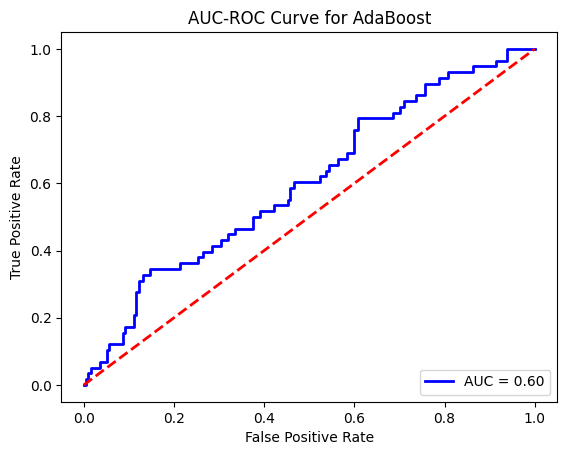

AUC for AdaBoost: 0.60



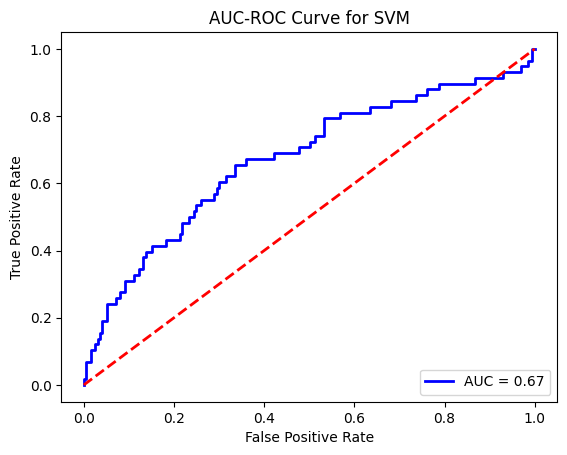

AUC for SVM: 0.67



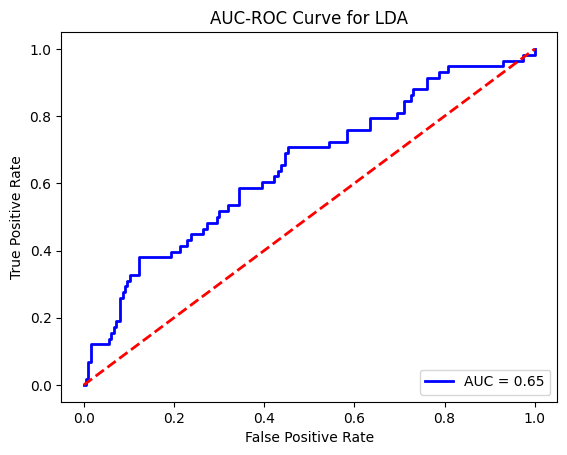

AUC for LDA: 0.65



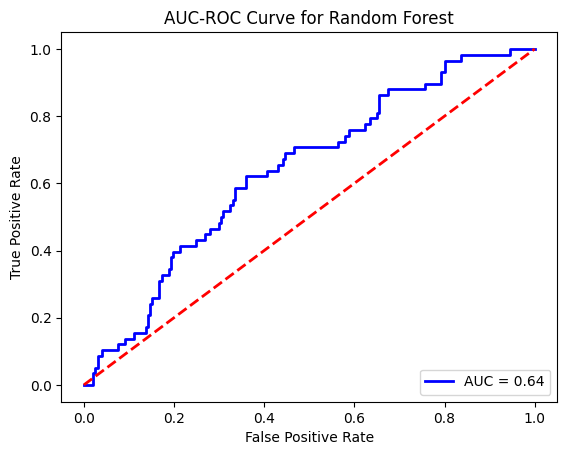

AUC for Random Forest: 0.64



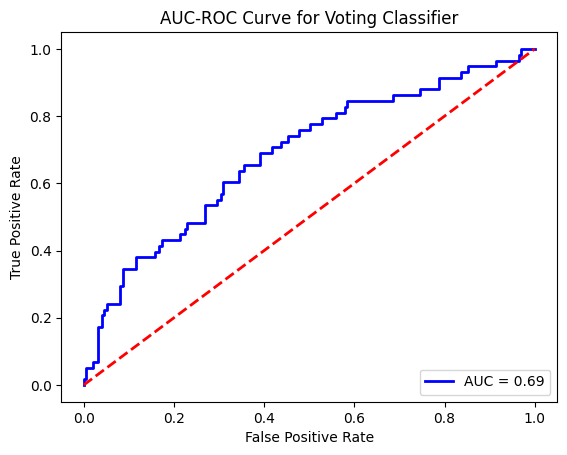

AUC for Voting Classifier: 0.69



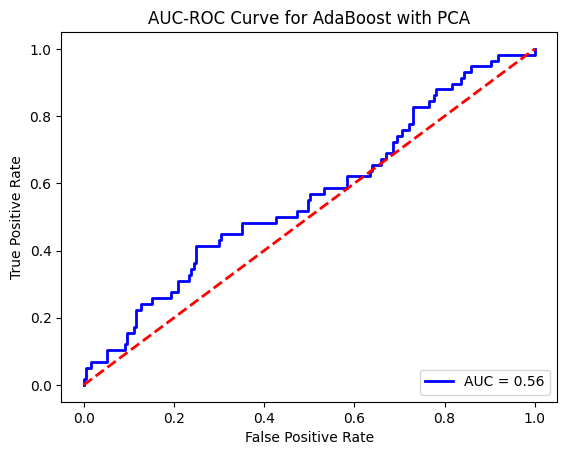

AUC for AdaBoost with PCA: 0.56



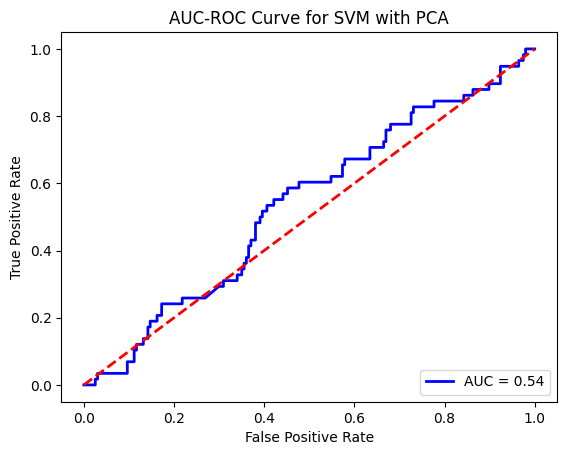

AUC for SVM with PCA: 0.54



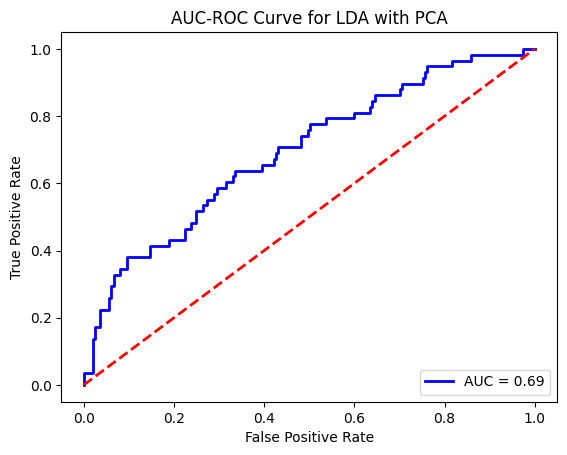

AUC for LDA with PCA: 0.69



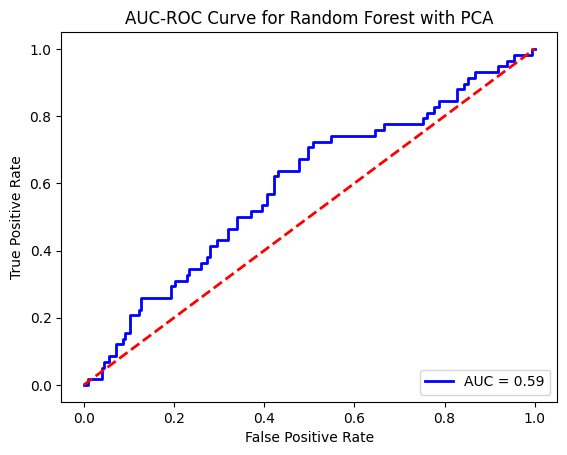

AUC for Random Forest with PCA: 0.59



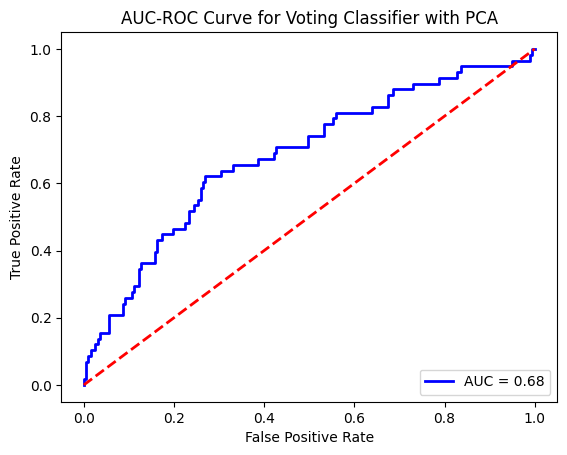

AUC for Voting Classifier with PCA: 0.68



In [70]:
# Function to plot AUC-ROC curves
def plot_auc_roc(model, X_test, y_test, model_name):
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_pred_prob = model.decision_function(X_test)
    else:
        raise AttributeError(f"The model {model_name} does not have predict_proba or decision_function attributes.")

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

    auc_score = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_score:.2f}')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'AUC-ROC Curve for {model_name}')
    plt.legend(loc='lower right')
    plt.show()

    print(f"AUC for {model_name}: {auc_score:.2f}\n")

plot_auc_roc(best_ada, X_test, y_test, "AdaBoost")
plot_auc_roc(best_svm, X_test, y_test, "SVM")
plot_auc_roc(best_lda, X_test, y_test, "LDA")
plot_auc_roc(best_rf, X_test, y_test, "Random Forest")
plot_auc_roc(best_voting, X_test, y_test, "Voting Classifier")

plot_auc_roc(best_ada_pca, X_test_pca, y_test_pca, "AdaBoost with PCA")
plot_auc_roc(best_svm_pca, X_test_pca, y_test_pca, "SVM with PCA")
plot_auc_roc(best_lda_pca, X_test_pca, y_test_pca, "LDA with PCA")
plot_auc_roc(best_rf_pca, X_test_pca, y_test_pca, "Random Forest with PCA")
plot_auc_roc(best_voting_pca, X_test_pca, y_test_pca, "Voting Classifier with PCA")

In [71]:
def evaluate_model(y_true, y_pred, model, X_test):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        decision_scores = model.decision_function(X_test)
        if decision_scores.ndim == 1 or decision_scores.shape[1] == 1:
            y_pred_prob = decision_scores.ravel()
        else:
            y_pred_prob = softmax(decision_scores, axis=1)[:, 1]
    else:
        y_pred_prob = None

    auc = roc_auc_score(y_true, y_pred_prob) if y_pred_prob is not None else "N/A"
    
    return accuracy, precision, recall, f1, auc

In [72]:
# Summarize results for all models
model_names = ['AdaBoost', 'SVM', 'LDA', 'Random Forest', 'Voting Classifier', 
               'AdaBoost with PCA', 'SVM with PCA', 'LDA with PCA', 'Random Forest with PCA', 'Voting Classifier with PCA']

metrics = []
metrics.append(evaluate_model(y_test, model_ada, best_ada, X_test))
metrics.append(evaluate_model(y_test, model_svm, best_svm, X_test))
metrics.append(evaluate_model(y_test, model_lda, best_lda, X_test))
metrics.append(evaluate_model(y_test, model_rf, best_rf, X_test))
metrics.append(evaluate_model(y_test, model_voting, best_voting, X_test))

metrics.append(evaluate_model(y_test_pca, model_ada_pca, best_ada_pca, X_test_pca))
metrics.append(evaluate_model(y_test_pca, model_svm_pca, best_svm_pca, X_test_pca))
metrics.append(evaluate_model(y_test_pca, model_lda_pca, {}, X_test_pca))  # LDA has no predict_proba
metrics.append(evaluate_model(y_test_pca, model_rf_pca, best_rf_pca, X_test_pca))
metrics.append(evaluate_model(y_test_pca, model_voting_pca, best_voting_pca, X_test_pca))

metrics_df = pd.DataFrame(metrics, columns=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'])
metrics_df['Model'] = model_names

metrics_df = metrics_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']]

In [73]:
metrics_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,AdaBoost,0.678431,0.318182,0.362069,0.338710,0.602923
1,SVM,0.764706,0.473684,0.310345,0.375000,0.673114
2,LDA,0.635294,0.326733,0.568966,0.415094,0.648871
3,Random Forest,0.741176,0.300000,0.103448,0.153846,0.639156
4,Voting Classifier,0.772549,0.500000,0.275862,0.355556,0.685892
5,AdaBoost with PCA,0.662745,0.315789,0.413793,0.358209,0.561789
6,SVM with PCA,0.580392,0.271028,0.500000,0.351515,0.536671
7,LDA with PCA,0.654902,0.352941,0.620690,0.450000,N/A
8,Random Forest with PCA,0.737255,0.333333,0.155172,0.211765,0.592421
9,Voting Classifier with PCA,0.701961,0.384615,0.517241,0.441176,0.683529


In [74]:
metrics_df.shape

(10, 6)

In [75]:
metrics_df.to_csv('../results/netea_bal_comb_corr_metrics_with_metadata.csv')